<html> <h1 style="font-style:bold; color:white;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:white;"> Week-5 </h1> </html>

<html> <h2 style="font-style:italic; color:white;"> Convolution Neural Networks </h2> </html>

<html> <h2 style="font-style:italic; color:white;"> Task 1 : </h2> </html>

#### Develop and evaluate an image classifier using Convolution Neural Network.

### The Data = CIFAR 10, Multiple Classes datset.

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

ttps://www.cs.toronto.edu/~kriz/cifar.html

Example of using Keras for CNNs. Use a famous data set, the CIFAR-10 dataset which consists of 10 different image types.

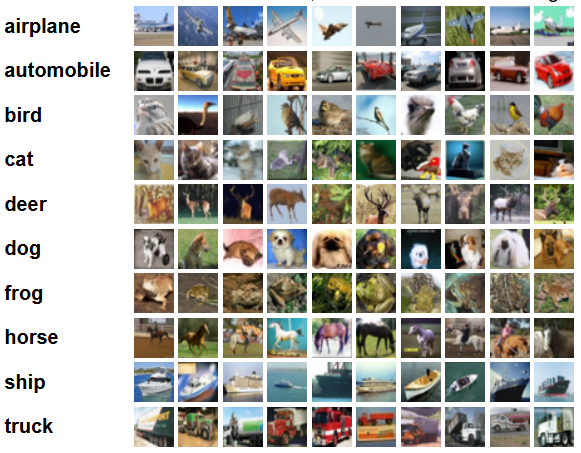

In [1]:
# Your code to import matplotlib, pandas and numpy libraries
#

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

##### Following code loads the CIFAR 10 datset.

___________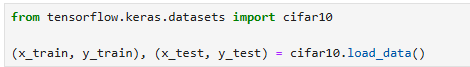

In [2]:

from tensorflow.keras.datasets import cifar10
# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

c:\Users\nisal\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
# Your code to print shapes of training and test data. Check how the data looks

# ...
# ...
x_train.shape, y_train.shape, x_test.shape, y_test.shape


((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [4]:
# Your code to print the shape of one image

print("Shape of one image:", x_train[0].shape)


Shape of one image: (32, 32, 3)


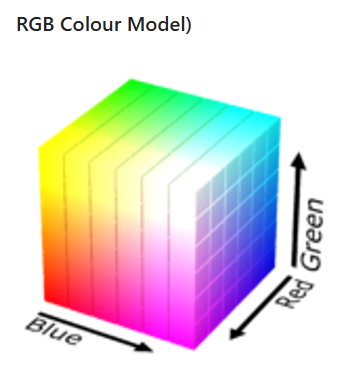

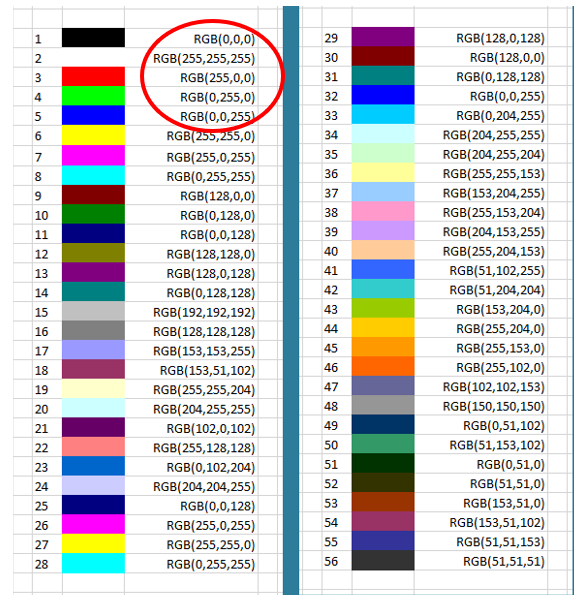

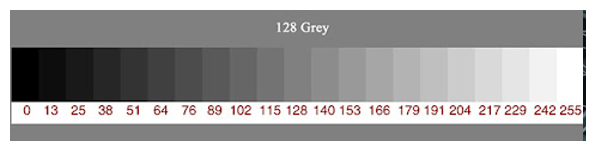

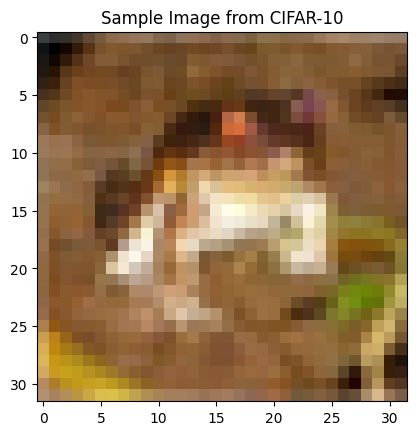

In [5]:
# Your code to show any sample image in the dataset. Use - plt.imshow()

plt.imshow(x_train[0])
plt.title("Sample Image from CIFAR-10")
plt.show()


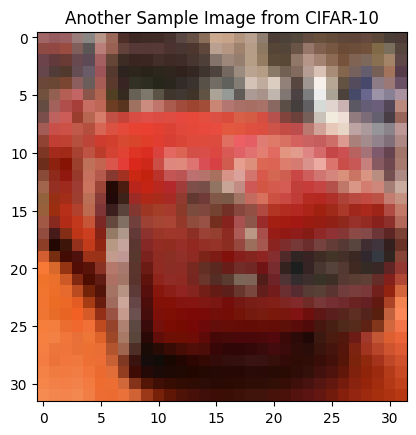

In [6]:
# Show any other image

plt.imshow(x_train[5])
plt.title("Another Sample Image from CIFAR-10")
plt.show()


____________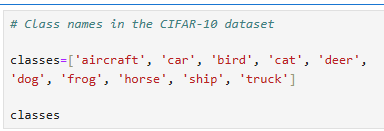

In [7]:
classes = ['airplane', 'car','bird','cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
classes

['airplane',
 'car',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

______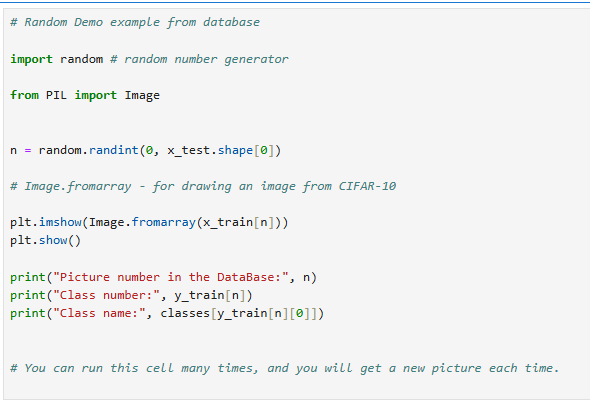

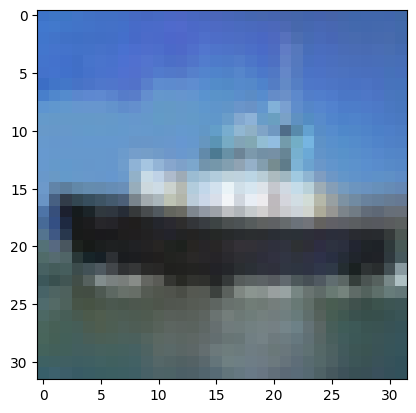

Picture number in the dataset: 365
Class number: [8]
Class label: ship


In [8]:
import random
from PIL import Image

n = random.randint(0, x_test.shape[0])  # Random index for test set

plt.imshow(Image.fromarray(x_train[n]))  # Display the image
plt.show()

print("Picture number in the dataset:", n)
print("Class number:", y_train[n])
print("Class label:", classes[y_train[n][0]])

## PreProcessing

Image index: 365
Array shape: (32, 32, 3)
Pixel values for the selected image (RGB):
[[[ 61 115 200]
  [ 62 118 198]
  [ 62 118 197]
  ...
  [ 65 103 172]
  [ 65 102 172]
  [ 64 104 167]]

 [[ 65 120 206]
  [ 66 121 204]
  [ 65 118 201]
  ...
  [ 68 105 173]
  [ 69 105 174]
  [ 66 106 171]]

 [[ 65 118 204]
  [ 66 116 201]
  [ 65 113 198]
  ...
  [ 71 106 174]
  [ 72 107 173]
  [ 67 105 171]]

 ...

 [[ 68  99  92]
  [ 67  96  90]
  [ 66  96  91]
  ...
  [ 58  83  86]
  [ 55  84  89]
  [ 53  84  91]]

 [[ 62  97  99]
  [ 63  96  98]
  [ 64  95  98]
  ...
  [ 58  82  89]
  [ 54  82  90]
  [ 50  81  90]]

 [[ 56  95 106]
  [ 61  97 109]
  [ 61  94 105]
  ...
  [ 58  80  92]
  [ 53  80  90]
  [ 50  81  91]]]


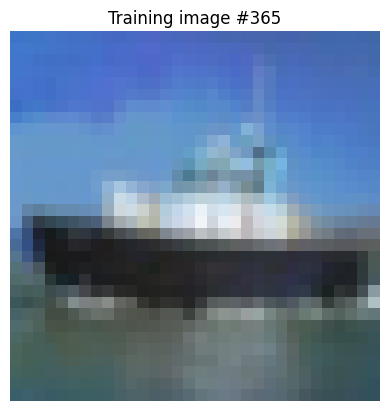


Red channel values:
[[61 62 62 ... 65 65 64]
 [65 66 65 ... 68 69 66]
 [65 66 65 ... 71 72 67]
 ...
 [68 67 66 ... 58 55 53]
 [62 63 64 ... 58 54 50]
 [56 61 61 ... 58 53 50]]


In [9]:
# Your code to print one image in digitals. Check what pixels look like.

# select a random index from the training set (or reuse the previously chosen `n` if available)
try:
    n  # if this variable exists from earlier cells
except NameError:
    n = random.randint(0, x_train.shape[0] - 1)

img = x_train[n]

print(f"Image index: {n}")
print(f"Array shape: {img.shape}")
print("Pixel values for the selected image (RGB):")
print(img)  # prints the full 3‑channel pixel array

# show the image visually as well
plt.imshow(img)
plt.title(f"Training image #{n}")
plt.axis('off')
plt.show()

# optionally examine a single channel or a flattened view
print("\nRed channel values:")
print(img[:, :, 0])


In [10]:
# Your code to print the shape of any image i.e particular value in the x_train


# Select a particular image by index
index = 25  # Change this to any index you want (0 to 49999 for training set)

print(f"Shape of image at index {index}:", x_train[index].shape)
print(f"Data type:", x_train[index].dtype)

# You can also print shapes of multiple images
print("\nShapes of first 5 training images:")
for i in range(5):
    print(f"  Image {i}: {x_train[i].shape}")


Shape of image at index 25: (32, 32, 3)
Data type: uint8

Shapes of first 5 training images:
  Image 0: (32, 32, 3)
  Image 1: (32, 32, 3)
  Image 2: (32, 32, 3)
  Image 3: (32, 32, 3)
  Image 4: (32, 32, 3)


In [11]:
# Your code to print the maximum value in x_train. Hint - Use .max()

max_value = x_train.max()
print(f"Maximum pixel value in x_train: {max_value}")
 
# Also check minimum value for reference
min_value = x_train.min()
print(f"Minimum pixel value in x_train: {min_value}")

Maximum pixel value in x_train: 255
Minimum pixel value in x_train: 0


____________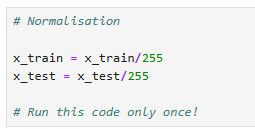

In [12]:
x_train = x_train / 255
x_test = x_test / 255

__________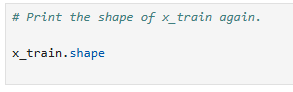

In [13]:
x_train.shape

(50000, 32, 32, 3)

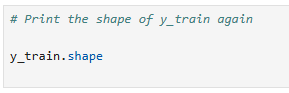

In [14]:
y_train.shape

(50000, 1)

## One hot vector encoding.
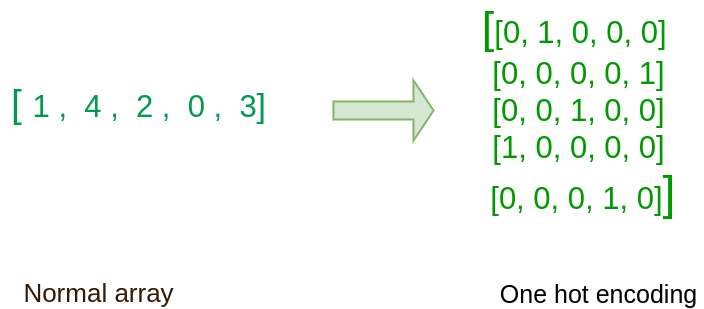


The "to_categorical()" is converting the integer value to binary categorical matrix : https://keras.io/api/utils/python_utils/#to_categorical-functionLinks to an external site.

________________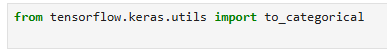

In [15]:
from tensorflow.keras.utils import to_categorical

___________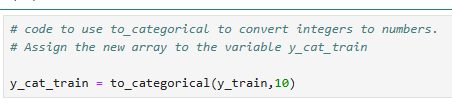

In [16]:
y_cat_train = to_categorical(y_train, 10)

In [17]:
# Your code to print the shape of the array y_cat_train

print("Shape of y_cat_train:", y_cat_train.shape)
print("Data type:", y_cat_train.dtype)

Shape of y_cat_train: (50000, 10)
Data type: float64


In [18]:
# Your code to print any single value in the array y_cat_train and print y_train with the same index.

# Compare the result for better understanding of "to_categorical()"

# Select an index to examine
idx = 5

print(f"Index: {idx}")
print(f"\nOriginal label (y_train[{idx}]):")
print(y_train[idx])
print(f"\nOne-hot encoded label (y_cat_train[{idx}]):")
print(y_cat_train[idx])
print(f"\nClass name: {classes[y_train[idx][0]]}")


Index: 5

Original label (y_train[5]):
[1]

One-hot encoded label (y_cat_train[5]):
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]

Class name: car


In [19]:
# Your code to:
# Convert y_test to the encoded vector in the same manner
# Assign it to the variable y_cat_test

y_cat_test = to_categorical(y_test, 10)


____________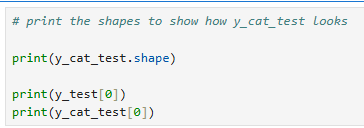

In [20]:
print(y_cat_test.shape)
print(y_test[0])
print(y_cat_test[0])

(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


-----------------

## Creating a CNN Model

_____________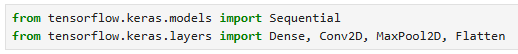

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense , Dropout

#### Please read the following links before creating code for the next cell

https://keras.io/api/layers/convolution_layers/convolution2d/
    
https://keras.io/api/layers/pooling_layers/max_pooling2d/

In [22]:
model = Sequential()

# CONVOLUTIONAL LAYER 1
model.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(32, 32, 3), activation='relu'))
# POOLING LAYER 1
model.add(MaxPool2D(pool_size=(2, 2)))

# CONVOLUTIONAL LAYER 2
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
# POOLING LAYER 2
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())

# DENSE LAYERS
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))  # 10 classes for CIFAR-10



c:\Users\nisal\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


__________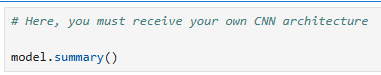

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,394 (1.21 MB)

 Trainable params: 316,394 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

### We could use early stopping in Keras to break from the training.
### What this does is for successive iterations it monitors the loss. If the loss does not decreases for a certain number of iterations denoted by variable 'patience' then the training stops.
### Following code shows how you can use early stopping.


___________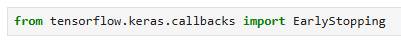

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

__________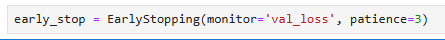

In [25]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [26]:
# Your code to compile the models (model.compile). 

# Use 'categorical cross entropy' as the loss function
# and use 'accuracy' as the metrics
# You can use the optimiser of your choice

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [27]:
# Your code to fit the model (model.fit). 

# Use additional parameter -  callbacks = [early_stop] to enable early stopping. 
# Use 'history' array to save the training parameters for each epoch

history = model.fit(x_train, y_cat_train,
                    epochs=25,
                    batch_size=32,
                    validation_data=(x_test, y_cat_test),
                    callbacks=[early_stop])



Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.4223 - loss: 1.5871 - val_accuracy: 0.5508 - val_loss: 1.2654
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5449 - loss: 1.2777 - val_accuracy: 0.6160 - val_loss: 1.0832
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.5969 - loss: 1.1446 - val_accuracy: 0.6429 - val_loss: 1.0033
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6283 - loss: 1.0551 - val_accuracy: 0.6629 - val_loss: 0.9525
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6530 - loss: 0.9839 - val_accuracy: 0.6859 - val_loss: 0.8946
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6734 - loss: 0.9303 - val_accuracy: 0.6769 - val_loss: 0.9152
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6919 - loss: 0.8795 - val_accuracy: 0.6990 - val_loss: 0.8670
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7025 -

______________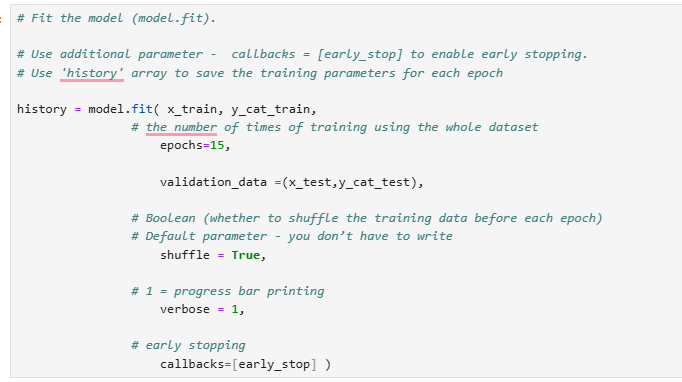

In [28]:
history = model.fit(x_train,y_cat_train,epochs=15,validation_data=(x_test, y_cat_test), shuffle= True,verbose=1,callbacks=[early_stop])

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.7327 - loss: 0.7491 - val_accuracy: 0.6970 - val_loss: 0.9010
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7415 - loss: 0.7216 - val_accuracy: 0.6985 - val_loss: 0.8978
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7513 - loss: 0.6927 - val_accuracy: 0.7013 - val_loss: 0.8983


##### You can save the model in a file. Following code shows how to do this.

________________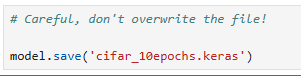

In [29]:
model.save('cifar_10epochs.keras')

##### Yiu can save the loss at every step. Following code shows how to do this. 

___________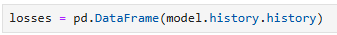

In [30]:
losses =pd.DataFrame(model.history.history)


In [31]:
# You code to print the first few rows of losses.

losses.head()


,accuracy,loss,val_accuracy,val_loss
0,0.73268,0.749112,0.6970,0.901005
1,0.74152,0.721602,0.6985,0.897842
2,0.75128,0.692658,0.7013,0.898316


#### Visualise a plot between accuracy vs val_accuracy for all steps.

#### x axis will have the steps (epochs) 
#### y axis will have accuracy and val_accuracy 


_________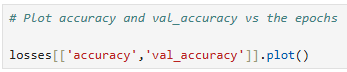

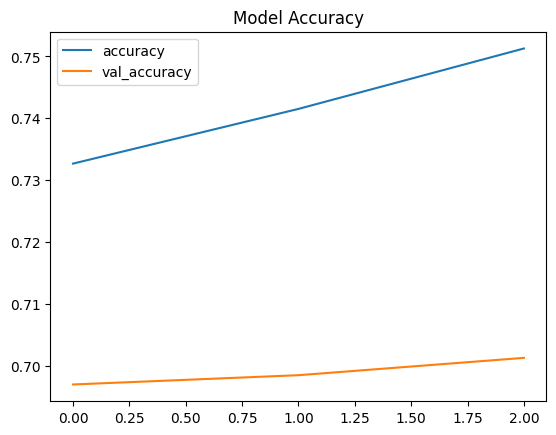

In [32]:
losses[['accuracy', 'val_accuracy']].plot()
plt.title('Model Accuracy')     
plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

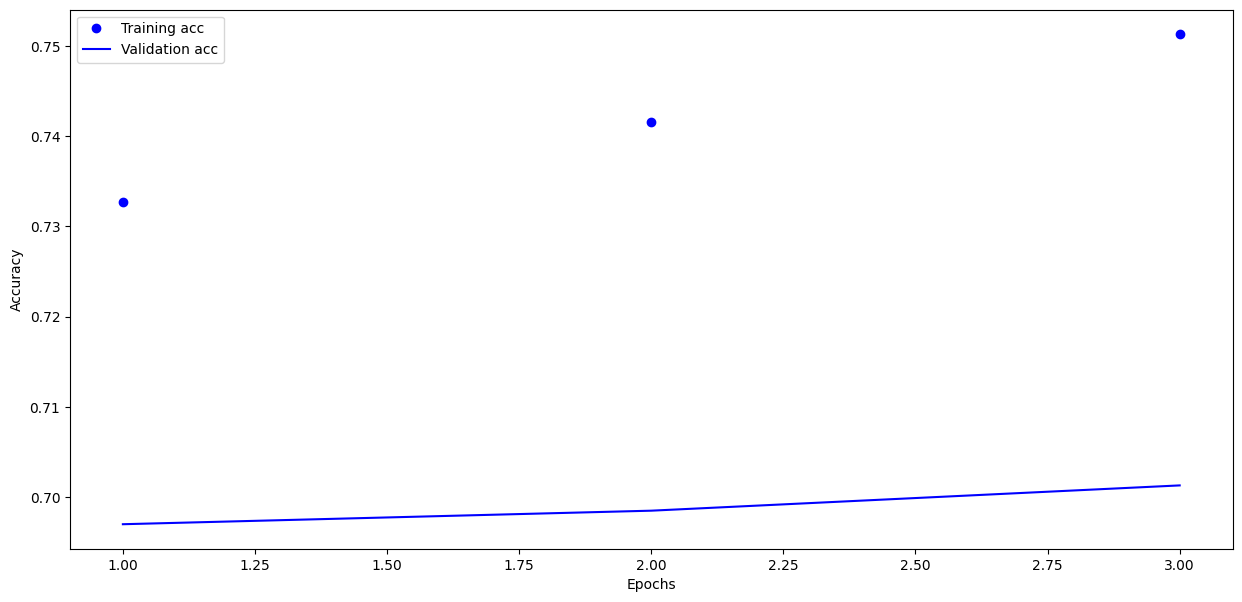

In [33]:
# Plot accuracy and val_accuracy for the neural network training process in more detail

history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

__________________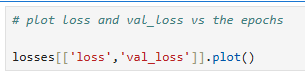

Text(0.5, 1.0, 'Model Loss')

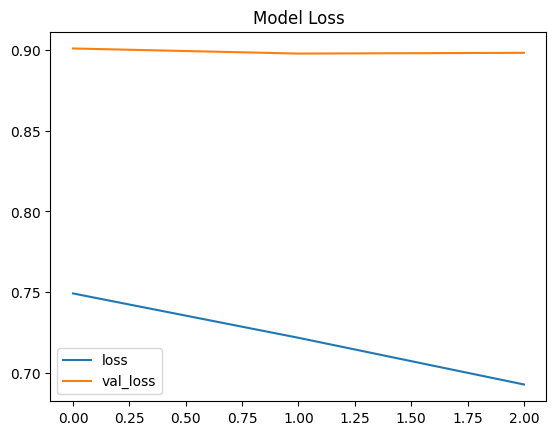

In [34]:
losses[['loss','val_loss']].plot()
plt.title('Model Loss')

_____________________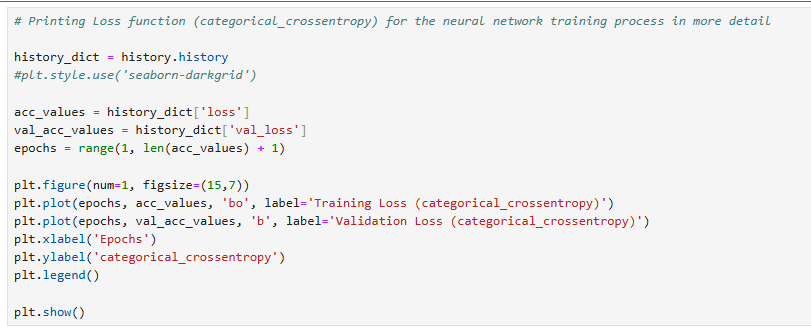

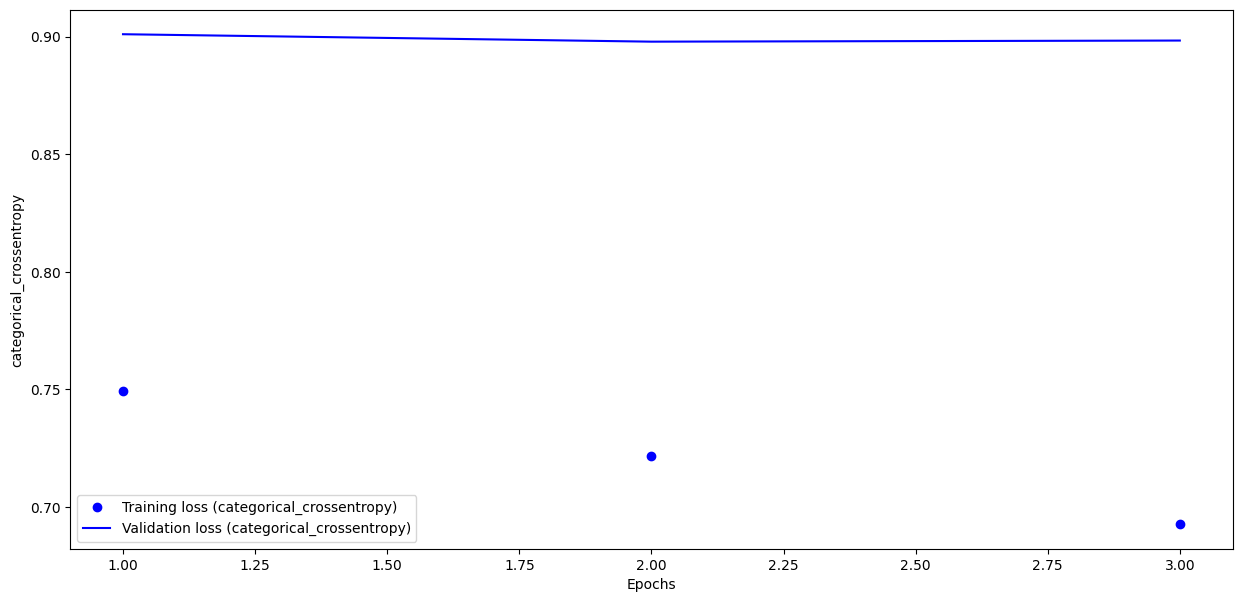

In [35]:
history_dict = history.history
acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)  

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss (categorical_crossentropy)')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss (categorical_crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('categorical_crossentropy')
plt.legend()
plt.show()


__________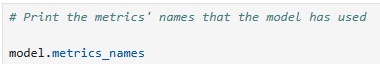

In [36]:
model.metrics_names

['loss', 'compile_metrics']

___________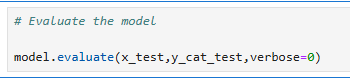

In [37]:
model.evaluate(x_test, y_cat_test, verbose=0)

[0.8983160257339478, 0.7013000249862671]

In [38]:
# Evaluate the model

model.evaluate(x_test,y_cat_test,verbose=0)

[0.8983160257339478, 0.7013000249862671]

___________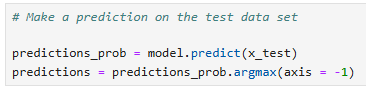

In [39]:
# Make a prediction on the test data set

predictions_prob = model.predict(x_test)
predictions = predictions_prob.argmax(axis = -1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


_______________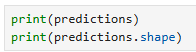

In [40]:
print(predictions)
print(predictions.shape)


[5 8 8 ... 5 1 7]
(10000,)


##### You could get the full classification report. 

_____________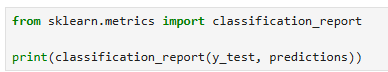

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.70      0.77      0.73      1000
           1       0.84      0.85      0.85      1000
           2       0.55      0.60      0.57      1000
           3       0.58      0.39      0.47      1000
           4       0.67      0.65      0.66      1000
           5       0.57      0.64      0.60      1000
           6       0.66      0.85      0.74      1000
           7       0.82      0.67      0.74      1000
           8       0.82      0.82      0.82      1000
           9       0.84      0.76      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



##### You could also get and plot confusion matrix.

https://github.com/matplotlib/matplotlib/issues/14751

______________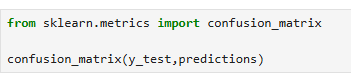

In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

[[772  11  72  13  12   5  15   5  71  24]
 [ 26 855   6   7   2   3  18   1  26  56]
 [ 66   4 601  30  74  77 103  25  10  10]
 [ 25   9 115 393  58 213 129  29  16  13]
 [ 37   1 101  39 646  33  90  39  14   0]
 [ 18   3  69 124  56 642  44  29   4  11]
 [  6   5  44  25  29  27 849   6   6   3]
 [ 29   4  61  27  76 102  20 671   2   8]
 [ 72  27  19  11   6   7  11   6 823  18]
 [ 51  93  12   7   5  14  14   9  34 761]]


_______________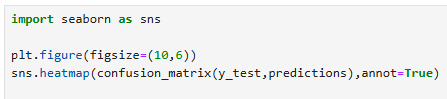

<Axes: >

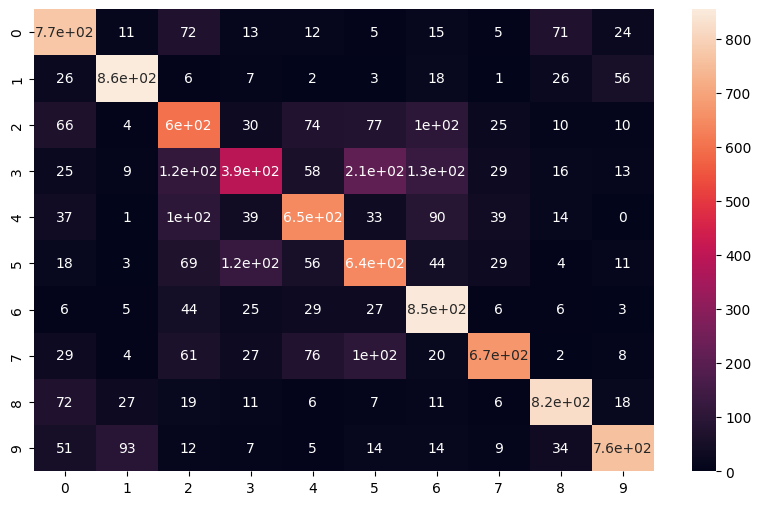

In [43]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True)

### Following code makes a prediction on specific image.

____________________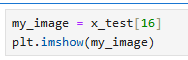

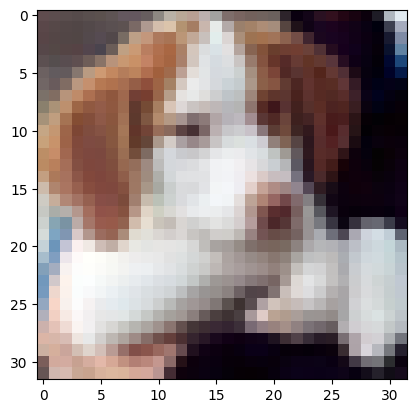

In [44]:
my_image = x_test[16]
plt.imshow(my_image)


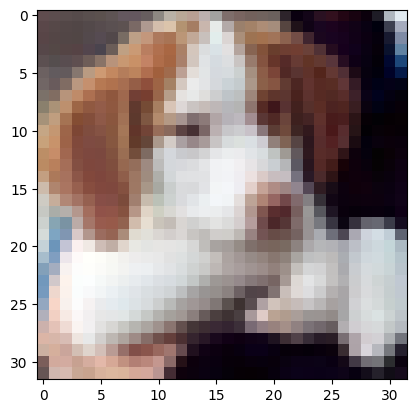

In [45]:
my_image = x_test[16]
plt.imshow(my_image)

______________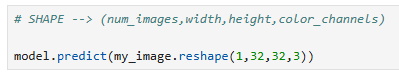

In [46]:
model.predict(my_image.reshape(1, 32, 32, 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([[8.3682306e-07, 1.1663287e-08, 1.8296333e-04, 1.1231970e-02,
        6.7895309e-07, 9.8857695e-01, 1.3042471e-06, 5.2544769e-06,
        3.2601417e-09, 9.4589602e-08]], dtype=float32)

In [47]:
# Find the highest probability value in the vector above. 
# What output value does it point to?

_______________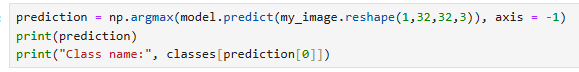

In [48]:
prediction = np.argmax(model.predict(my_image.reshape(1, 32, 32, 3)), axis = -1)
print(prediction)
print("Class Name" , classes[prediction[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[5]
Class Name dog


### Let's use a trained neural network
You can run the following code many times

Note the recognition probabilities for each image

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


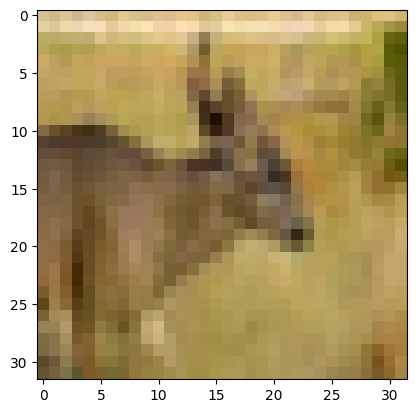

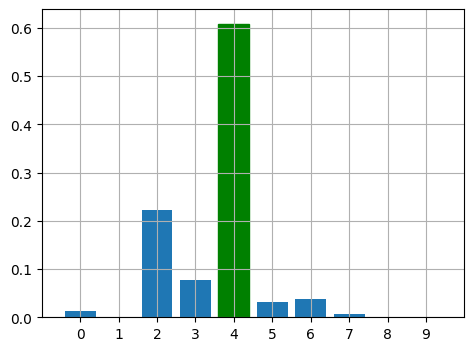

The predicted answer: deer 
 Correct answer: deer
['aircraft', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [49]:
from tensorflow.keras.preprocessing.image import array_to_img

# Class names in the CIFAR-10 dataset
classes=['aircraft', 'car', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']

# we take a random element 'random.randint()' from the test sample
# and observe: the neural network will guess or not
index = random.randint(0, x_test.shape[0])
plt.imshow(array_to_img(x_test[index]))

# test image conversion
x = x_test[index]
x = np.expand_dims(x, axis=0)

# start recognition
prediction = model.predict(x)
sample = x

# converting the result from one hot encoding format
ans = np.argmax(prediction)

fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(1, 2, 2)
bar_list = ax.bar(np.arange(10), prediction[0], align='center')
bar_list[ans].set_color('g')
ax.set_xticks(np.arange(10))
ax.set_xlim([-1, 10])
ax.grid('on')

plt.show()

print('The predicted answer: {}'.format((classes[ans])), "\n",
     'Correct answer: {}'.format(classes[y_test[index][0]]) )

print(classes)


# You can run this cell many times, and each time you will get a new picture,
# which this neural network will recognise with the probability indicated on the graph.

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot of the model's summary

### 2. Please ensure to document in your laboratory logbook a graphical representation depicting the train loss and validation loss trends.

### 3. Based on this analysis, determine the optimal number of epochs for training your model. 

<html> <h2 style="font-style:italic; color:blue;"> Task 2 (Optional): </h2> </html>

#### Evaluate your model for different optimisers available in the Keras. 

https://keras.io/api/optimizers/

- Store the optimisers in an array.
- Use for loop to fit, compile, and  test your model.
- Plot the accuracy vs optimiser


In [50]:
# Create a list containing the names of optimisers (Don't use 'AdamW' and 'Adafactor')
# Create an empty list to store scores

# For every optimiser
   # compile your model
   # fit your model, use epochs=3 for each optimiser (otherwise the training will take a long time)
   # using model.evaluate() find score and append the score in a list

# Plot score vs optimiser 